## How to use our algorithm on a bifiltered graph
Input: 
Assume you have a `firep` file that inclues a bifiltered and one-critical graph:
- graph: $G = (V,E)$
- function $f: G \rightarrow \mathbb R^2$ satisfying 
    - for any $e = (u,v) \in E$, $f(u), f(v) \leq f(e)$

Output: 
- Absolute Betti numbers $\beta_0(H_0), \beta_1(H_0), \beta_2(H_0)$, and $\beta_0(H_1)$. 
- A discretized Hibert function shown as a matrix.

Note:

Many bifiltration uses floating point numbers, which means comparing them can be a issue. For example, you can consider $0.009$ is the same as $0.01$ if your tolerance is $0.1$. 

Thus, instead of providing a pre-defined $\epsilon$ as the tolerance, we suggest you make the comparison in `Python` and store the sorted index into the `firep` file. 

In other words, the `firep` file only contains grade information as `index_of_x_in_sorted_x_coordinates` and  `index_of_y_in_sorted_y_coordinates`.

Later, if you want to visuallize the original scale of $x$ and $y$ coordinates, you can use the sorted unique x and y cooridnates lists, as shown below.  

In [1]:
import graph_mph
import matplotlib.pyplot as plt
import numpy as np

# build a bi-filtration from a point cloud
bifi = graph_mph.BiFiltration(
    filtration_type="firep",  # filtration type can be "degree", "degree_rational", "ball_density", "ball_density_rational", "firep"
    file_path="figure1_data.firep",
)

graded_graph = bifi.ggraph
res = graph_mph.compute_MPH0(graded_graph)

In [2]:
print(f"x coordinates: {bifi.get_x_coords()}")
print(f"y coordinates: {bifi.get_y_coords()}")

x coordinates: [1, 2, 3, 5, 6]
y coordinates: [1, 2, 3, 5, 6]


In [3]:
res

{'b_0': [(0, 2), (1, 0)],
 'b_1': [(2, 3), (3, 2)],
 'b_2': [(3, 3)],
 'b_0_1': [(3, 3), (4, 1), (4, 4)],
 'M': [(1, 1, -1), (2, 1, 1), (1, 2, -1), (2, 2, 1)]}

In [4]:
def compute_approximated_Hilbert_matrix(
    res: dict[str, list[tuple[int, int]]],
    table_x_coords: list[float],
    table_y_coords: list[float],
    target_matrix_shape: tuple[int, int],
):
    # convert the graded betti numbers in indices to filtration values
    b_0_values = graph_mph.map_graded_betti_numbers_to_filtration_values(
        res["b_0"], table_x_coords, table_y_coords
    )
    b_0_values = np.array(b_0_values)
    b_1_values = graph_mph.map_graded_betti_numbers_to_filtration_values(
        res["b_1"], table_x_coords, table_y_coords
    )
    b_1_values = np.array(b_1_values)
    b_2_values = graph_mph.map_graded_betti_numbers_to_filtration_values(
        res["b_2"], table_x_coords, table_y_coords
    )
    b_2_values = np.array(b_2_values)

    target_m, target_n = target_matrix_shape
    xs = np.linspace(table_x_coords[0], table_x_coords[-1], target_m)
    ys = np.linspace(table_y_coords[0], table_y_coords[-1], target_n)
    matrix_meshgrid = np.meshgrid(xs, ys, indexing="ij")

    cumsum_b_0 = np.zeros((target_m, target_n), dtype=np.int32)
    cumsum_b_1 = np.zeros((target_m, target_n), dtype=np.int32)
    cumsum_b_2 = np.zeros((target_m, target_n), dtype=np.int32)
    for i in range(target_m):
        for j in range(target_n):
            s, k = matrix_meshgrid[0][i][j], matrix_meshgrid[1][i][j]
            # counts the number of rows (x,y) in b_0_values that satisfy x <= s and y <= k
            cumsum_b_0[i, j] = np.sum((b_0_values[:, 0] <= s) & (b_0_values[:, 1] <= k))
            cumsum_b_1[i, j] = np.sum((b_1_values[:, 0] <= s) & (b_1_values[:, 1] <= k))
            cumsum_b_2[i, j] = np.sum((b_2_values[:, 0] <= s) & (b_2_values[:, 1] <= k))

    return cumsum_b_0, cumsum_b_1, cumsum_b_2

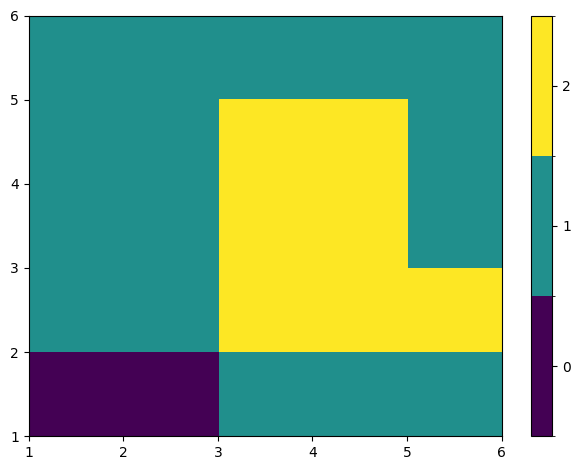

In [ ]:
# in order to plot, you need to get the x and y coordinates of the points
table_x_coords = bifi.get_x_coords()  # you can use your own x and y coordinates
table_y_coords = bifi.get_y_coords()

# compute the approximated Hilbert matrix
cum_0, cum_1, cum_2 = compute_approximated_Hilbert_matrix(
    res, table_x_coords, table_y_coords, (50, 50)
)

approx_hilbert_matrix = cum_0 - cum_1 + cum_2
# map the value greater to 4 to 4
approx_hilbert_matrix = np.clip(approx_hilbert_matrix, 0, 5)
# matrix_to_plot = np.log(approx_hilbert_matrix + 1)
matrix_to_plot = approx_hilbert_matrix

# plot the approximated Hilbert matrix (distance vs ball density)
xrange = np.min(table_x_coords), np.max(table_x_coords)
yrange = np.min(table_y_coords), np.max(table_y_coords)
discrete_plot, cbar = graph_mph.draw_discrete_matrix(
    matrix_to_plot, x_axis_range=yrange, y_axis_range=xrange, origin="lower"
)
discrete_plot.tight_layout()
# discrete_plot.savefig("Hibert_matrix_ball_density_rips_blob_400.pdf", dpi=300)
discrete_plot.show()